In [5]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading dataset
df = pd.read_csv("../data/train.csv")   #Change file path as per your directory structure
df.head(10)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [7]:
# Dropping unnecessary ('id' & 'Surname') columns
df = df.drop(['id', 'Surname', ], axis = 1)

In [8]:
# Checking for null entries
df.isnull().sum()

CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# Finding is there any duplicate (repeated) row?
df.duplicated().sum()

30

In [10]:
# Dropping these duplicate rows
df = df.drop_duplicates()

In [11]:
# Scaling the 'Tenure' from years to days
df['Tenure'] = df['Tenure']*365

#### Checking unique entries in categorical columns

In [13]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [14]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
# Checking range of Age
l = min(df['Age'])
m = max(df['Age'])
print("Minimum age = ", l)
print("Maximum age = ", m)

Minimum age =  18.0
Maximum age =  92.0


In [16]:
df['Age'].unique()

array([33.  , 40.  , 34.  , 36.  , 30.  , 37.  , 43.  , 27.  , 71.  ,
       47.  , 25.  , 55.  , 61.  , 35.  , 41.  , 44.  , 26.  , 39.  ,
       31.  , 58.  , 49.  , 32.  , 50.  , 28.  , 45.  , 52.  , 29.  ,
       38.  , 54.  , 56.  , 46.  , 42.  , 64.  , 20.  , 21.  , 23.  ,
       48.  , 59.  , 51.  , 24.  , 53.  , 62.  , 57.  , 22.  , 66.  ,
       67.  , 19.  , 73.  , 60.  , 63.  , 65.  , 75.  , 68.  , 69.  ,
       76.  , 18.  , 70.  , 81.  , 74.  , 72.  , 77.  , 82.  , 79.  ,
       92.  , 80.  , 78.  , 83.  , 36.44, 85.  , 32.34, 84.  ])

### Removing invalid Age entries
Two age values (36.44 and 32.34) were found to be decimal values
that appear to be data entry errors, real ages are whole numbers.
These two rows were removed as they represent erroneous entries,
not genuine outliers.

In [17]:
# Removing two enetries from age (36.44, 32.34)
values_to_remove = [36.44, 32.34]
# Removing rows
df = df[~df['Age'].isin(values_to_remove)]

In [18]:
df['NumOfProducts'].unique()

array([2, 1, 3, 4], dtype=int64)

In [19]:
df['HasCrCard'].unique()

array([1., 0.])

In [20]:
df['IsActiveMember'].unique()

array([0., 1.])

In [21]:
df['Exited'].unique()

array([0, 1], dtype=int64)

In [22]:
# Checking range of Credit scores
a = min(df['CreditScore'])
b = max(df['CreditScore'])
print("Minimum credit score = ", a)
print("Maximum credit score = ", b)

Minimum credit score =  350
Maximum credit score =  850


### Columns: Age, HasCrCard & IsActiveMember have float datatype which is supposed to be int

In [23]:
# Checking datatypes of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165002 entries, 0 to 165033
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CustomerId       165002 non-null  int64  
 1   CreditScore      165002 non-null  int64  
 2   Geography        165002 non-null  object 
 3   Gender           165002 non-null  object 
 4   Age              165002 non-null  float64
 5   Tenure           165002 non-null  int64  
 6   Balance          165002 non-null  float64
 7   NumOfProducts    165002 non-null  int64  
 8   HasCrCard        165002 non-null  float64
 9   IsActiveMember   165002 non-null  float64
 10  EstimatedSalary  165002 non-null  float64
 11  Exited           165002 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 16.4+ MB


In [25]:
# List of columns with wrong datatypes
numeric_cols = ['Age', 'HasCrCard', 'IsActiveMember'] # List of columns to change
# Changing datatype
df[numeric_cols] = df[numeric_cols].astype(int)

### Encoding categorical columns (Geography and Gender)

In [27]:
df['Geography'] = df['Geography'].replace({'France':1, 'Germany':2, 'Spain':3})
df['Gender'] = df['Gender'].replace({'Female':1, 'Male':2})

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12564\1543317975.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Geography'] = df['Geography'].replace({'France':1, 'Germany':2, 'Spain':3})
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12564\1543317975.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Female':1, 'Male':2})


### Visualisation for outliers (Box plots)

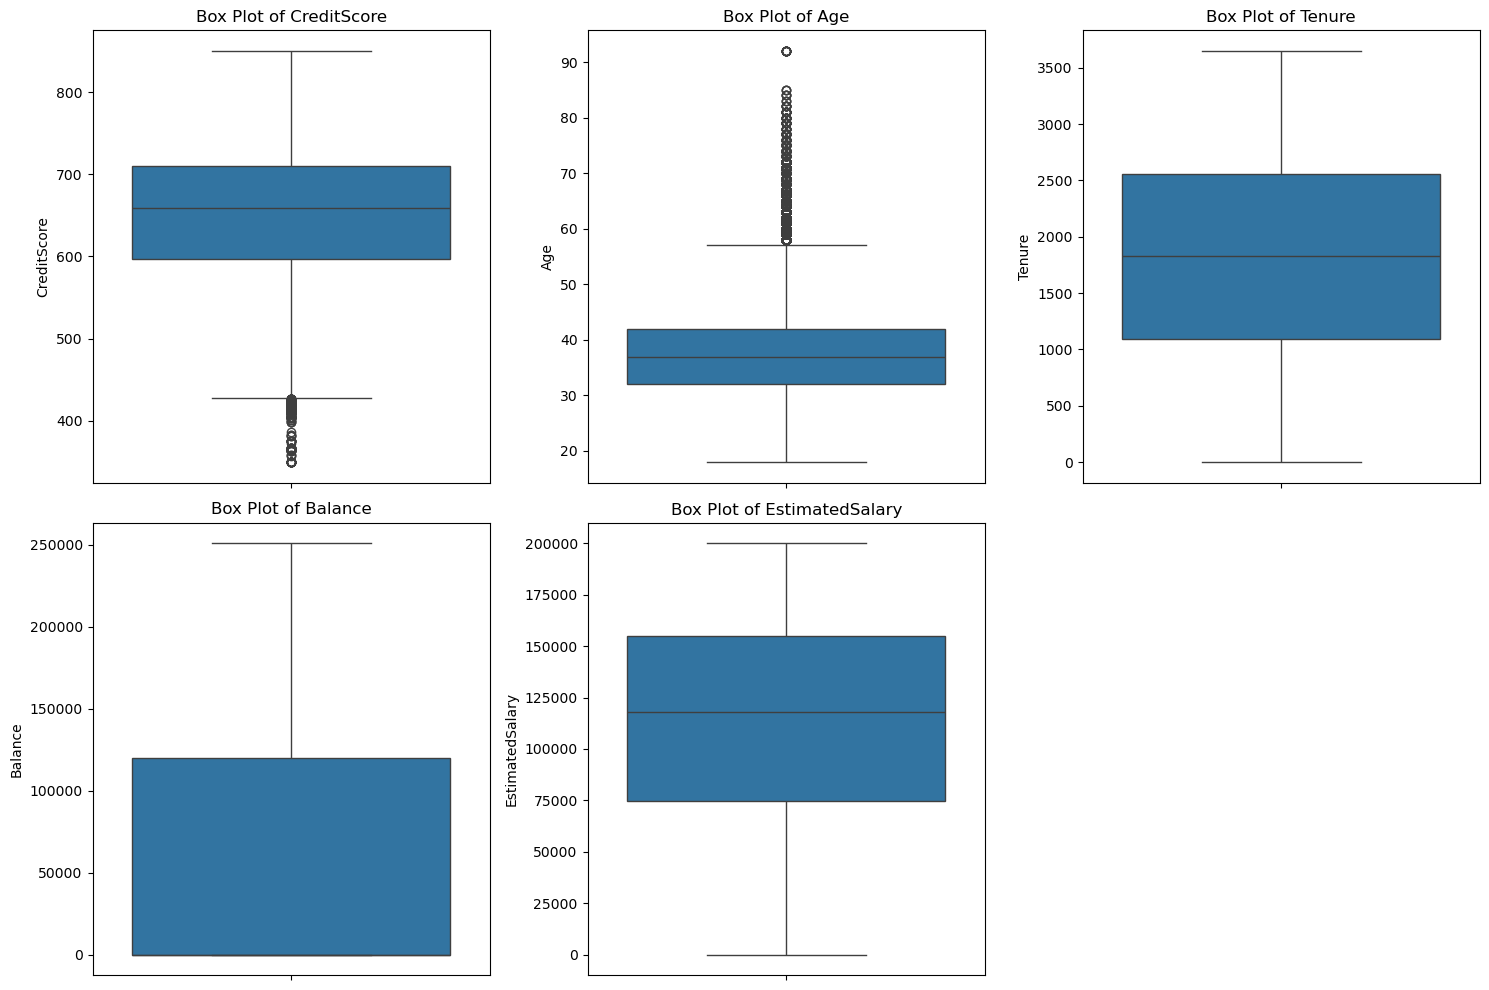

In [29]:
# List of columsn that might contain outliers
columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(15, 10))  # Adjust figure size for all subplots
for i, var in enumerate(columns, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns, ith subplot
    sns.boxplot(y=df[var])  # Use 'y' to make the box plots vertical
    plt.ylabel(var)
    plt.title(f"Box Plot of {var}")
plt.tight_layout()
plt.show()

In [30]:
# Finding the unique outliers from both the columns
columns = ['CreditScore', 'Age']
# Finding outliers
for i in columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]
    if not outliers.empty:
        unique_outliers = outliers.unique()
        num_outliers = len(outliers)
        print(f"Outliers in {i} (Total: {num_outliers}):")
        print(unique_outliers)
    else:
        print(f"No outliers found in {i}")

Outliers in CreditScore (Total: 253):
[413 359 415 427 367 420 411 424 399 426 425 408 405 401 416 363 422 350
 418 404 417 376 365 410 414 419 421 386 383 412 358 423 382 373]
Outliers in Age (Total: 6391):
[71 61 58 64 59 62 66 67 73 60 63 65 75 68 69 76 70 81 74 72 77 82 79 92
 80 78 83 85 84]


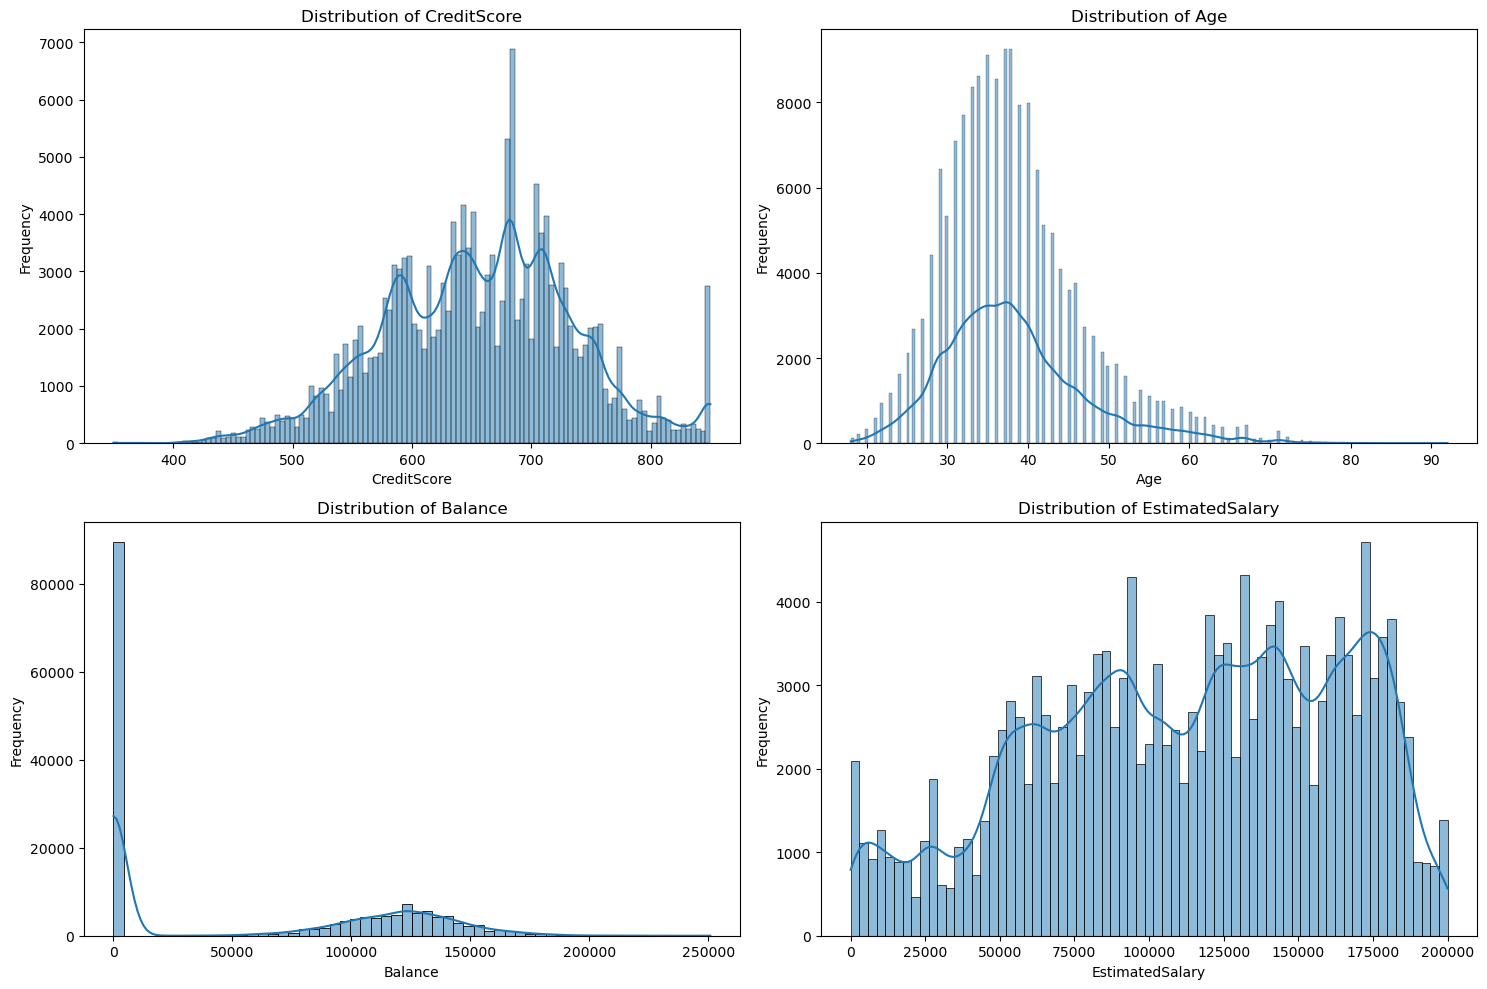

In [35]:
# Checking for normality
numerical_vars = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# Using Seaborn (combined plot)
plt.figure(figsize=(15, 10))  # Adjust figure size for all subplots
for i, var in enumerate(numerical_vars, 1): #Enumerate to get index for subplots
    plt.subplot(2, 2, i) # 2 rows, 2 columns, ith subplot
    sns.histplot(df[var], kde=True) #kde adds a Kernel Density Estimate
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {var}")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12564\1806661941.py:23: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, hist = False, kde = True,
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\distributions.py:2496: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12564\1806661941.py:27: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot

Lambda value used for Transformation: -0.24589289915500895


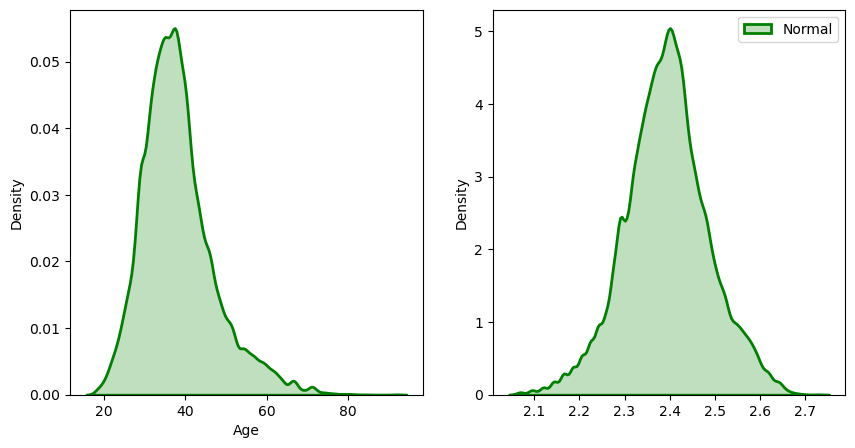

In [69]:
# Python3 code to show Box-cox Transformation 
# of non-normal data

# import modules
import numpy as np
from scipy import stats

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt


data = df['Age']

# transform training data & save lambda value
fitted_data, fitted_lambda = stats.boxcox(data)

# creating axes to draw plots
fig, ax = plt.subplots(1, 2)

# plotting the original data(non-normal) and 
# fitted data (normal)
sns.distplot(data, hist = False, kde = True,
			kde_kws = {'shade': True, 'linewidth': 2}, 
			label = "Non-Normal", color ="green", ax = ax[0])

sns.distplot(fitted_data, hist = False, kde = True,
			kde_kws = {'shade': True, 'linewidth': 2}, 
			label = "Normal", color ="green", ax = ax[1])

# adding legends to the subplots
plt.legend(loc = "upper right")

# rescaling the subplots
fig.set_figheight(5)
fig.set_figwidth(10)

print(f"Lambda value used for Transformation: {fitted_lambda}")


In [120]:
df['transf_Age'] = (df['Age']**-0.24589 - 1)/(-0.24589)

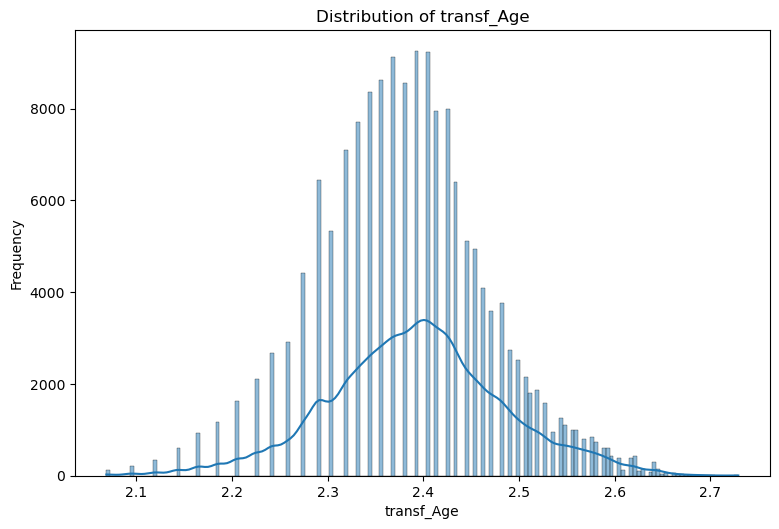

In [122]:
# Checking for normality of transformed variables
numerical_vars = ['transf_Age']

# Using Seaborn (combined plot)
plt.figure(figsize=(15, 10))  # Adjust figure size for all subplots
for i, var in enumerate(numerical_vars, 1): #Enumerate to get index for subplots
    plt.subplot(2, 2, i) # 2 rows, 2 columns, ith subplot
    sns.histplot(df[var], kde=True) #kde adds a Kernel Density Estimate
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {var}")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
df = df.drop("Balance", axis=1)